In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../csv/Customers.csv")
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
157223,550196,23158,SET OF 5 LUCKY CAT MAGNETS,1,15/04/2011 10:09,2.08,14796.0,United Kingdom
380328,569767,84997B,CHILDRENS CUTLERY RETROSPOT RED,4,06/10/2011 11:24,4.15,14849.0,United Kingdom
153286,549735,21935,SUKI SHOULDER BAG,20,12/04/2011 08:42,1.65,13824.0,United Kingdom
357287,568075,90201C,RED ENAMEL FLOWER RING,1,23/09/2011 14:21,2.95,14652.0,United Kingdom
376184,569514,22835,HOT WATER BOTTLE I AM SO POORLY,8,04/10/2011 13:56,4.95,15228.0,United Kingdom
123531,546896,22534,MAGIC DRAWING SLATE SPACEBOY,8,17/03/2011 18:24,0.83,NaN,United Kingdom
103881,545081,22838,3 TIER CAKE TIN RED AND CREAM,1,28/02/2011 10:35,14.95,16057.0,United Kingdom
483586,577504,22994,TRAVEL CARD WALLET RETROSPOT,5,20/11/2011 12:36,0.42,14159.0,United Kingdom
391049,570650,21166,COOK WITH WINE METAL SIGN,3,11/10/2011 13:13,2.08,13263.0,United Kingdom
165666,550819,22854,CREAM SWEETHEART EGG HOLDER,2,20/04/2011 17:37,4.95,17530.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [6]:
# Let's convert the proper data types first

In [7]:
df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format="%d/%m/%Y %H:%M")

In [9]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [10]:
# Now let's extract some datetime features from the timestamp column

In [11]:
# Common datetime features
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceIsMonthEnd'] = df['InvoiceDate'].dt.is_month_end
df['InvoiceIsMonthStart'] = df['InvoiceDate'].dt.is_month_start
# ISO week (safe for pandas >= 1.1.0)
df['InvoiceWeek'] = df['InvoiceDate'].dt.isocalendar().week.astype('Int64')

In [12]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,InvoiceIsMonthEnd,InvoiceIsMonthStart,InvoiceWeek
294644,562716,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,16,2011-08-08 15:35:00,3.75,14257.0,United Kingdom,2011,8,8,0,15,False,False,32
331024,565937,23426,METAL SIGN DROP YOUR PANTS,6,2011-09-08 10:52:00,2.89,13468.0,United Kingdom,2011,9,8,3,10,False,False,36
92511,544193,22629,SPACEBOY LUNCH BOX,12,2011-02-17 08:23:00,1.95,12431.0,Belgium,2011,2,17,3,8,False,False,7
359042,568170,22730,ALARM CLOCK BAKELIKE IVORY,1,2011-09-25 13:08:00,3.75,16931.0,United Kingdom,2011,9,25,6,13,False,False,38
301707,563351,22567,20 DOLLY PEGS RETROSPOT,25,2011-08-15 14:17:00,1.45,16902.0,United Kingdom,2011,8,15,0,14,False,False,33


In [13]:
df.dtypes

InvoiceNo                         str
StockCode                         str
Description                       str
Quantity                        int64
InvoiceDate            datetime64[us]
UnitPrice                     float64
CustomerID                    float64
Country                           str
InvoiceYear                     int32
InvoiceMonth                    int32
InvoiceDay                      int32
InvoiceDayOfWeek                int32
InvoiceHour                     int32
InvoiceIsMonthEnd                bool
InvoiceIsMonthStart              bool
InvoiceWeek                     Int64
dtype: object

In [14]:
# Now, let's do label encoding for Boolean columns
df['InvoiceIsMonthEnd'] = df['InvoiceIsMonthEnd'].astype(str).map({'True':0, 'False':1})
df['InvoiceIsMonthStart'] = df['InvoiceIsMonthStart'].astype(str).map({'True':0, 'False':1})

In [15]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,InvoiceIsMonthEnd,InvoiceIsMonthStart,InvoiceWeek
467642,576364,22960,JAM MAKING SET WITH JARS,3,2011-11-14 17:40:00,4.25,15009.0,United Kingdom,2011,11,14,0,17,1,1,46
375141,569416,22639,SET OF 4 NAPKIN CHARMS HEARTS,6,2011-10-04 10:15:00,2.55,13801.0,United Kingdom,2011,10,4,1,10,1,1,40
283252,561704,21935,SUKI SHOULDER BAG,2,2011-07-29 11:07:00,1.65,14606.0,United Kingdom,2011,7,29,4,11,1,1,30
171043,551351,85061W,WHITE JEWELLED HEART DECORATION,24,2011-04-28 10:20:00,0.64,14298.0,United Kingdom,2011,4,28,3,10,1,1,17
499382,578666,23370,SET 36 COLOURING PENCILS DOILY,16,2011-11-24 17:06:00,1.25,17727.0,United Kingdom,2011,11,24,3,17,1,1,47


In [16]:
df['InvoiceIsMonthEnd'] = df['InvoiceIsMonthEnd'].astype(int)
df['InvoiceIsMonthStart'] = df['InvoiceIsMonthStart'].astype(int)

In [17]:
# Now, let's create dummies for Country column
df = pd.get_dummies(df, columns=['Country'], dtype=int)

In [18]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,InvoiceYear,InvoiceMonth,InvoiceDay,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
269831,560504,21354,TOAST ITS - BEST MUM,12,2011-07-19 11:47:00,1.25,13081.0,2011,7,19,...,0,0,0,0,0,0,0,0,1,0
191441,553363,22488,NATURAL SLATE RECTANGLE CHALKBOARD,12,2011-05-16 14:19:00,1.65,13650.0,2011,5,16,...,0,0,0,0,0,0,0,0,1,0
4985,536833,21349,IVY HEART WREATH,2,2010-12-02 17:48:00,6.75,18239.0,2010,12,2,...,0,0,0,0,0,0,0,0,1,0
434277,574036,22281,EASTER TREE YELLOW BIRDS,2,2011-11-02 12:46:00,5.95,16607.0,2011,11,2,...,0,0,0,0,0,0,0,0,1,0
392241,570690,21905,MORE BUTTER METAL SIGN,1,2011-10-11 16:37:00,1.63,NaN,2011,10,11,...,0,0,0,0,0,0,0,0,1,0


In [19]:
# Since we have nulls in the columns that are basically of no use to us, we can safetly ignore them.
df = df.drop(['InvoiceNo','StockCode','Description','InvoiceDate','CustomerID'], axis=1)

In [20]:
# Let's now check the outliers in the feature variables
df.describe()

,Quantity,UnitPrice,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,InvoiceIsMonthEnd,InvoiceIsMonthStart,InvoiceWeek,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
count,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.0,...,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,2010.921609,7.553128,15.023096,2.431277,13.078729,0.964540,0.967650,30.729049,...,0.000107,0.000018,0.000423,0.004674,0.000853,0.003694,0.000537,0.000125,0.914320,0.000823
std,218.081158,96.759853,0.268787,3.509055,8.664063,1.844709,2.443270,0.184939,0.176929,15.146243,...,0.010345,0.004296,0.020552,0.068208,0.029186,0.060669,0.023167,0.011201,0.279892,0.028676
min,-80995.000000,-11062.060000,2010.000000,1.000000,1.000000,0.000000,6.000000,0.000000,0.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.250000,2011.000000,5.000000,7.000000,1.000000,11.000000,1.000000,1.000000,18.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,3.000000,2.080000,2011.000000,8.000000,15.000000,2.000000,13.000000,1.000000,1.000000,34.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,10.000000,4.130000,2011.000000,11.000000,22.000000,4.000000,15.000000,1.000000,1.000000,45.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,80995.000000,38970.000000,2011.000000,12.000000,31.000000,6.000000,20.000000,1.000000,1.000000,51.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


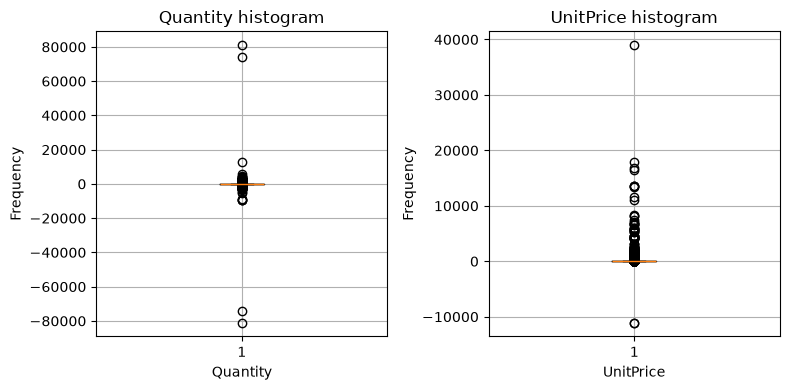

In [21]:
# Columns like quantity and unit price are showing up some strange min and max values, let's address those first!
fig, ax = plt.subplots(1,2,figsize=(8,4),dpi=100)
ax[0].boxplot(df['Quantity'])
ax[0].set_xlabel("Quantity")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Quantity histogram")
ax[0].grid(True)

ax[1].boxplot(df['UnitPrice'])
ax[1].set_xlabel("UnitPrice")
ax[1].set_ylabel("Frequency")
ax[1].set_title("UnitPrice histogram")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [22]:
def outlier_treatment(value, upper_limit, lower_limit):
    if value <= upper_limit and value >= lower_limit:
        return value
    elif value > upper_limit:
        return upper_limit
    elif value < lower_limit:
        return lower_limit

In [23]:
#Clearly, we can see the outliers in the data!
# let's now treat these outliers properly
# we will try to preserve 99% of the data in case of Quantity
quan_upper_limit = df['Quantity'].quantile(0.99)
quan_lower_limit = df['Quantity'].quantile(0.02)
quan_upper_limit, quan_lower_limit

(np.float64(100.0), np.float64(1.0))

In [24]:
df['Quantity'] = df['Quantity'].map(lambda Quantity: outlier_treatment(Quantity,quan_upper_limit,quan_lower_limit))

In [25]:
# Now, let's process UnitPrice feature variable as well
price_upper_limit = df['UnitPrice'].quantile(0.99)
price_lower_limit = df['UnitPrice'].quantile(0.01)
price_upper_limit, price_lower_limit

(np.float64(18.0), np.float64(0.19))

In [26]:
df['UnitPrice'] = df['UnitPrice'].map(lambda UnitPrice: outlier_treatment(UnitPrice,price_upper_limit,price_lower_limit))

In [27]:
df.describe()

,Quantity,UnitPrice,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,InvoiceIsMonthEnd,InvoiceIsMonthStart,InvoiceWeek,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
count,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.0,...,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000
mean,8.648924,3.249324,2010.921609,7.553128,15.023096,2.431277,13.078729,0.964540,0.967650,30.729049,...,0.000107,0.000018,0.000423,0.004674,0.000853,0.003694,0.000537,0.000125,0.914320,0.000823
std,15.216234,3.298825,0.268787,3.509055,8.664063,1.844709,2.443270,0.184939,0.176929,15.146243,...,0.010345,0.004296,0.020552,0.068208,0.029186,0.060669,0.023167,0.011201,0.279892,0.028676
min,1.000000,0.190000,2010.000000,1.000000,1.000000,0.000000,6.000000,0.000000,0.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.250000,2011.000000,5.000000,7.000000,1.000000,11.000000,1.000000,1.000000,18.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,3.000000,2.080000,2011.000000,8.000000,15.000000,2.000000,13.000000,1.000000,1.000000,34.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,10.000000,4.130000,2011.000000,11.000000,22.000000,4.000000,15.000000,1.000000,1.000000,45.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,100.000000,18.000000,2011.000000,12.000000,31.000000,6.000000,20.000000,1.000000,1.000000,51.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
df.sample(10)

,Quantity,UnitPrice,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,InvoiceIsMonthEnd,InvoiceIsMonthStart,InvoiceWeek,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
376584,25.0,0.42,2011,10,4,1,14,1,1,40,...,0,0,0,0,0,0,0,0,0,0
170475,12.0,2.10,2011,4,27,2,14,1,1,17,...,0,0,0,0,0,0,0,0,1,0
40641,1.0,16.98,2010,12,21,1,15,1,1,51,...,0,0,0,0,0,0,0,0,1,0
400089,12.0,1.65,2011,10,16,6,16,1,1,41,...,0,0,0,0,0,0,0,0,1,0
20905,2.0,8.47,2010,12,9,3,14,1,1,49,...,0,0,0,0,0,0,0,0,1,0
170072,1.0,10.95,2011,4,27,2,13,1,1,17,...,0,0,0,0,0,0,0,0,1,0
490738,1.0,1.63,2011,11,22,1,15,1,1,47,...,0,0,0,0,0,0,0,0,1,0
157966,2.0,16.63,2011,4,15,4,10,1,1,15,...,0,0,0,0,0,0,0,0,1,0
294826,12.0,1.45,2011,8,8,0,16,1,1,32,...,0,0,0,0,0,0,0,0,1,0
167495,2.0,1.95,2011,4,21,3,18,1,1,16,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# Cool, now our data is ready for modelling! Let's save a copy of our dataset!
# df.to_csv('../csv/Customers_cleaned.csv')

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [31]:
scaled_df = pd.DataFrame(scaled_data)
scaled_df.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
455288,-0.502682,0.151774,0.291649,0.982280,-0.579763,0.308300,-0.441511,0.191738,0.182844,0.942212,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
527066,0.220230,-0.897085,0.291649,1.267257,-1.156860,-1.317975,0.786353,0.191738,0.182844,1.206304,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
346915,-0.436963,-0.354467,0.291649,0.412326,0.459012,-1.317975,-0.850799,0.191738,0.182844,0.480050,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
254904,-0.502682,0.770177,0.291649,-0.157629,-0.926021,0.308300,1.195641,0.191738,0.182844,-0.246203,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
23510,6.003533,-0.766736,-3.428776,1.267257,-0.579763,0.850391,-0.850799,0.191738,0.182844,1.206304,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
51331,-0.502682,0.291218,0.291649,-1.867492,-0.579763,-1.317975,0.377065,0.191738,0.182844,-1.896779,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
267744,1.008863,-0.857677,0.291649,-0.157629,0.343592,-1.317975,-0.850799,0.191738,0.182844,-0.114157,...,-0.010346,-0.004296,48.635531,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,-3.266692,-0.0287
390381,-0.174086,-0.211992,0.291649,0.697303,-0.464343,-0.775883,-1.260087,0.191738,0.182844,0.678119,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
67234,-0.502682,2.034264,0.291649,-1.867492,0.689851,0.850391,1.604929,0.191738,0.182844,-1.830756,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287
228546,-0.502682,-0.490880,0.291649,-0.442606,-0.002666,-0.233792,0.786353,0.191738,0.182844,-0.444272,...,-0.010346,-0.004296,-0.020561,-0.068529,-0.029211,-0.060894,-0.023179,-0.011203,0.306120,-0.0287


In [32]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)

In [33]:
kmeans.fit(scaled_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [34]:
pred = kmeans.predict(scaled_df)
pred

array([0, 0, 0, ..., 3, 3, 3], shape=(541909,), dtype=int32)

In [35]:
pd.Series(pred).value_counts()

0    531053
3      8557
2      2002
1       297
Name: count, dtype: int64

In [36]:
kmeans.inertia_

24263026.886248913

In [37]:
SSE = []

In [38]:
for clusters in range(1,100):
    kmeans = KMeans(n_clusters=clusters)
    kmeans.fit(scaled_df)
    SSE.append(kmeans.inertia_)

In [39]:
frame = pd.DataFrame({'Clusters': range(1,100), 'SSE': SSE})

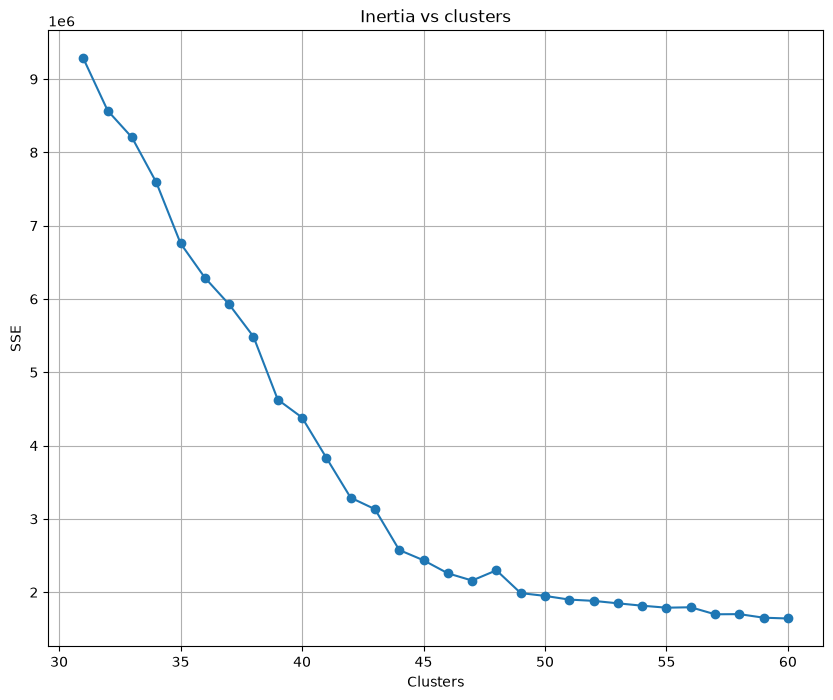

In [42]:
plt.figure(figsize=(10,8))
plt.plot(frame['Clusters'][30:60], frame['SSE'][30:60], marker='o')
plt.xlabel("Clusters")
plt.ylabel("SSE")
plt.title("Inertia vs clusters")
plt.grid()

In [43]:
# from this graph, we're inclined to use clusters as 44 or 47. Let's check one by one how it works!

In [44]:
kmeans_44 = KMeans(n_clusters=44)
kmeans_44.fit(scaled_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",44
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [45]:
pred = kmeans_44.predict(scaled_df)
pred

array([0, 0, 0, ..., 3, 3, 3], shape=(541909,), dtype=int32)

In [46]:
pd.Series(pred).value_counts()

4     146791
2     143061
1      98716
41     37176
31     36157
43     17409
0      16168
15      9495
3       8557
11      8196
10      2533
9       2371
8       2069
14      2002
6       1519
25      1259
13      1086
27       803
5        758
22       695
16       622
7        462
17       446
42       401
12       389
30       358
18       341
39       297
20       291
32       288
24       229
40       182
23       151
29       146
28       127
38        68
19        61
34        58
26        45
21        35
35        32
33        30
37        19
36        10
Name: count, dtype: int64

In [47]:
kmeans_44.inertia_

2619062.160121085

In [ ]:
# Now let's check for clusters=47

In [48]:
kmeans_47 = KMeans(n_clusters=47)
kmeans_47.fit(scaled_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",47
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [49]:
pred = kmeans_47.predict(scaled_df)
pred

array([34, 34, 34, ...,  6,  6,  6], shape=(541909,), dtype=int32)

In [50]:
pd.Series(pred).value_counts()

1     86884
45    84129
40    74440
5     70801
2     66747
26    36666
46    29635
44    17247
34    16011
0     12918
8      9495
6      8557
7      8196
32     2533
9      2371
10     2069
4      2002
19     1519
12     1259
17     1086
23      803
13      758
11      695
14      622
22      462
30      446
20      401
3       389
39      358
21      341
15      297
18      291
24      288
16      229
35      182
29      151
25      146
37      127
27       68
28       61
42       58
31       45
38       35
36       32
33       30
43       19
41       10
Name: count, dtype: int64

In [51]:
kmeans_47.inertia_

2151005.440073135

In [52]:
# definitely, 47 works well, so that will be our final n_clusters value!